In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import stan
from pathlib import Path
from pyproj import Geod
from scipy.spatial import cKDTree

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Drone data
sizes = pd.read_csv('rawdata/territory_sizes_2023.txt', sep='	')
sizes = sizes.rename(columns={'Territory': 'territory_id', 'sizes': 'size'})
ninetyfive_percentile = sizes['size'].quantile(0.95)

locations2023 = pd.read_csv('rawdata/territories_2023.txt', header=None, names=['territory_id', 'longitude', 'latitude', 'altitude', 'blank'])
locations2023 = locations2023.loc[:, ['territory_id', 'longitude', 'latitude']]
locations2023 = locations2023.merge(sizes[['territory_id', 'size']], on='territory_id', how='left')

locations2024 = pd.read_csv('rawdata/territories_2024.txt', header=None, names=['territory_id', 'longitude', 'latitude', 'altitude', 'blank'])
locations2024 = locations2024.loc[:, ['territory_id', 'longitude', 'latitude']]

geod = Geod(ellps='WGS84')

In [4]:
## Match 2024 territories to 2023 territories using longitude/latitude
xy_2023 = locations2023[['longitude', 'latitude']].to_numpy()
xy_2024 = locations2024[['longitude', 'latitude']].to_numpy()

tree_2023 = cKDTree(xy_2023)
_, nearest_2023_row = tree_2023.query(xy_2024, k=1)

nearest_distance_m = []

for row_2024, row_2023 in enumerate(nearest_2023_row):
    _, _, distance_m = geod.inv(locations2024.loc[row_2024, 'longitude'], locations2024.loc[row_2024, 'latitude'],
                                locations2023.loc[row_2023, 'longitude'], locations2023.loc[row_2023, 'latitude'])

    nearest_distance_m.append(distance_m)

correspondences = pd.DataFrame({
    'territory_id_2024': locations2024['territory_id'].astype(int),
    'longitude_2024': locations2024['longitude'],
    'latitude_2024': locations2024['latitude'],
    'nearest_2023_row': nearest_2023_row,
    'territory_id_2023': locations2023.iloc[nearest_2023_row]['territory_id'].astype(int).to_numpy(),
    'longitude_2023': locations2023.iloc[nearest_2023_row]['longitude'].to_numpy(),
    'latitude_2023': locations2023.iloc[nearest_2023_row]['latitude'].to_numpy(),
    'distance_m': nearest_distance_m
})

## If multiple 2024 territories claim the same 2023 territory, keep the closest one
correspondences = correspondences.sort_values('distance_m').drop_duplicates('territory_id_2023').sort_values('territory_id_2023').reset_index(drop=True)
correspondences.head()


,territory_id_2024,longitude_2024,latitude_2024,nearest_2023_row,territory_id_2023,longitude_2023,latitude_2023,distance_m
0,26,74.436963,27.800044,0,1,74.436945,27.800021,3.105089
1,58,74.436612,27.799956,2,3,74.436602,27.799934,2.584933
2,59,74.436796,27.799803,3,4,74.436794,27.799810,0.766251
3,166,74.437142,27.799795,4,5,74.437163,27.799771,3.299700
4,165,74.437060,27.799882,5,6,74.437010,27.799881,4.956709


In [5]:
## Mark correspondences as reused if the 2024 territory falls within the reuse radius
correspondences['reused'] = (correspondences['distance_m'] <= ninetyfive_percentile).astype(int)

## Add reuse status back to locations2023
locations2023['reused'] = locations2023['territory_id'].isin(correspondences.loc[correspondences['reused'] == 1, 'territory_id_2023']).astype(int)

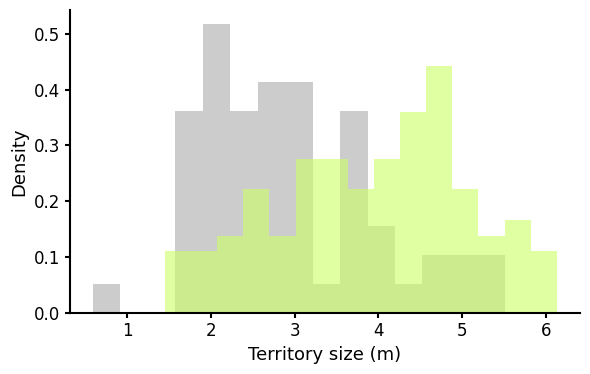

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))

sizes_not_reused = locations2023.loc[locations2023['reused'] == 0, 'size']
sizes_reused = locations2023.loc[locations2023['reused'] == 1, 'size']

## Plot histograms
ax.hist(sizes_not_reused, bins=15, density=True, color='black', alpha=0.2)
ax.hist(sizes_reused, bins=15, density=True, color='#CCFF66', alpha=0.6)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Territory size (m)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [38]:
size_centred = locations2023['size'] - locations2023['size'].mean()
size_z = np.array(size_centred / locations2023['size'].std())

## Specify size axis
s_min, s_max = float(size_centred.min()), float(size_centred.max())
s_grid = np.linspace(s_min, s_max, 200)
s_original = s_grid * locations2023['size'].std() + locations2023['size'].mean()

In [39]:
## Model territory reuse as a function of its size
reuse_mod = """
data {
    int<lower=1> n_points;
    array[n_points] int<lower=0, upper=1> reuse;
    vector[n_points] size;
}

parameters {
    real alpha;
    real beta;
}

model {
    alpha ~ normal(0, 1);
    beta  ~ normal(0, 1);

    reuse ~ bernoulli_logit(alpha + beta * size);
}
"""

In [40]:
reuse_data = {
    'n_points': len(locations2023),
    'reuse': locations2023['reused'].astype(int).values,
    'size': size_z
}

posterior = stan.build(reuse_mod, data=reuse_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 5.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.54 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 5.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.53 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.48 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.45 seconds.
  Adjust your expectations accordingly!


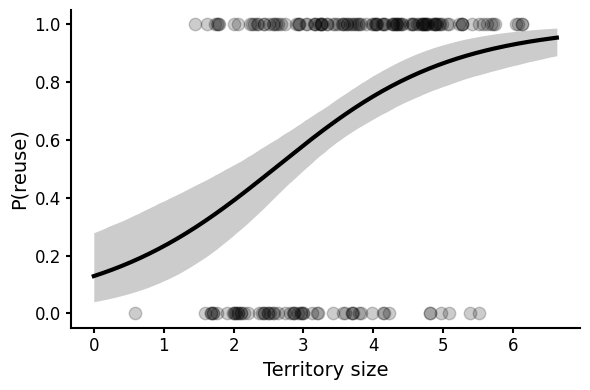

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))

# Compute posterior P(reuse) distribution and back-transform to return to original units 
mu = fit['alpha'].reshape(-1,1) + fit['beta'].reshape(-1,1) * s_grid[None,:]
y = scipy.special.expit(mu)
y_mean = np.mean(y, axis=0)
y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

# Plot model fits
ax.plot(s_original, y_mean, linewidth=3, color='black')
ax.fill_between(s_original, y_lower, y_upper, color='black', alpha=0.2, linewidth=0)

# Add scatter to the plot
ax.scatter(locations2023['size'], locations2023['reused'], s=80, color='black', edgecolor='black', alpha=0.2, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Territory size', fontsize=14)
ax.set_ylabel('P(reuse)', fontsize=14)

plt.tight_layout()
plt.savefig(out_dir/'territory_reuse.png', dpi=300, bbox_inches='tight')

In [7]:
## Model female visits as a function of the territory size
female_visit_mod = """
data {
    int<lower=1> n_points;
    array[n_points] int<lower=0, upper=1> visits;
    vector[n_points] size;
}

parameters {
    real alpha;
    real beta;
}

model {
    alpha ~ normal(0, 1);
    beta  ~ normal(0, 1);

    visits ~ bernoulli_logit(alpha + beta * size);
}
"""

In [8]:
visit_data = {
    'n_points': len(locations2023),
    'visits': locations2023['female_visit'].astype(int).values,
    'size': size_z
}

posterior = stan.build(female_visit_mod, data=visit_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

NameError: name 'df' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

# Compute posterior P(reuse) distribution and back-transform to return to original units 
mu = fit['alpha'].reshape(-1,1) + fit['beta'].reshape(-1,1) * s_grid[None,:]
y = scipy.special.expit(mu)
y_mean = np.mean(y, axis=0)
y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

# Plot model fits
ax.plot(s_original, y_mean, linewidth=3, color='black')
ax.fill_between(s_original, y_lower, y_upper, color='black', alpha=0.2, linewidth=0)

# Add scatter to the plot
ax.scatter(locations2023['size'], locations2023['reused'], s=80, color='black', edgecolor='black', alpha=0.2, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Territory size', fontsize=14)
ax.set_ylabel('P(reuse)', fontsize=14)

plt.tight_layout()
# plt.savefig(out_dir/'female_visits.png', dpi=300, bbox_inches='tight')